In [93]:
# --- Standard library ---
from pathlib import Path
import sys
import json
from datetime import datetime

# Ensure the repository root is on sys.path for local imports
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# --- Third-party ---
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

# --- Local imports ---
from src.dataset.dataloader import create_dataloaders
from src.models.FiveCharCNN import FiveCharCaptchaCNN

In [ ]:
# =========================
# Config
# =========================

EXPERIMENTS_DIR = REPO_ROOT / "experiments"

RUN_NAME = f"test_run_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
RUN_DIR = EXPERIMENTS_DIR / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = RUN_DIR / "best_model.pt"
LAST_MODEL_PATH = RUN_DIR / "last_model.pt"
HISTORY_PATH = RUN_DIR / "training_history.json"
CONFIG_PATH = RUN_DIR / "config.json"
CURVES_PATH = RUN_DIR / "training_curves.png"


# =========================
# Core task config
# =========================

NUM_CHAR_CLASSES = 51
LABEL_LENGTH = 5


# =========================
# Training config
# =========================

BATCH_SIZE = 50
NUM_EPOCHS = 30
LEARNING_RATE = 3e-4


# =========================
# Dataset split config
# =========================

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

RANDOM_SEED = 69
TRAINING = True
SHUFFLE_TRAIN = True

NUM_WORKERS = 0
PIN_MEMORY = False
DROP_LAST = False

SUBSET_FRACTION = 1.0
RETURN_FILENAMES = False


# =========================
# Debug config
# =========================

TINY_OVERFIT = True
TINY_OVERFIT_SIZE = 32

SAVE_PLOTS = True
PRINT_BATCH_SHAPES = True


# =========================
# Device config
# =========================

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")
print(f"Run directory: {RUN_DIR}")

Using device: mps
Run directory: /Users/marc/Documents/VS-Code Projects/captcha-ai/experiments/test_run_20260315_233040


Using device: mps
Run directory: /Users/marc/Documents/VS-Code Projects/captcha-ai/experiments/test_run_20260316_022307


In [120]:
CONFIG = {
    "num_char_classes": NUM_CHAR_CLASSES,
    "label_length": LABEL_LENGTH,
    
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "random_seed": RANDOM_SEED,
    
    "shuffle_train": SHUFFLE_TRAIN,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "drop_last": DROP_LAST,
    
    "subset_fraction": SUBSET_FRACTION,
    
    "tiny_overfit": TINY_OVERFIT,
    "tiny_overfit_size": TINY_OVERFIT_SIZE
}

In [121]:
with open(CONFIG_PATH, "w") as f:
    json.dump(CONFIG, f, indent=4)

In [122]:
# =========================
# Create dataloaders
# =========================
train_loader, val_loader, test_loader, char_to_idx, idx_to_char = create_dataloaders(
    batch_size=BATCH_SIZE,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    random_seed=RANDOM_SEED,
    training=TRAINING,
    shuffle_train=SHUFFLE_TRAIN,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=DROP_LAST,
    subset_fraction=SUBSET_FRACTION,
    return_filenames=RETURN_FILENAMES,
)

print("Original loaders created.")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")


# =========================
# Tiny-overfit mode
# =========================

if TINY_OVERFIT:
    print(f"\nTiny-overfit mode enabled with {TINY_OVERFIT_SIZE} samples.")

    # Grab underlying datasets from the loaders
    train_dataset = train_loader.dataset
    val_dataset = val_loader.dataset

    # Restrict both train and val to the same tiny subset for debugging
    tiny_indices = list(range(min(TINY_OVERFIT_SIZE, len(train_dataset))))

    tiny_train_dataset = Subset(train_dataset, tiny_indices)
    tiny_val_dataset = Subset(val_dataset, list(range(min(TINY_OVERFIT_SIZE, len(val_dataset)))))

    train_loader = DataLoader(
        tiny_train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=DROP_LAST,
    )

    val_loader = DataLoader(
        tiny_val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=DROP_LAST,
    )

    print("Tiny-overfit loaders created.")
    print(f"Train batches: {len(train_loader)}")
    print(f"Val batches:   {len(val_loader)}")


# =========================
# Inspect one batch
# =========================

batch = next(iter(train_loader))

if isinstance(batch, (list, tuple)):
    if len(batch) == 2:
        images, labels = batch
        filenames = None
    elif len(batch) == 3:
        images, labels, filenames = batch
    else:
        raise ValueError(f"Unexpected batch length: {len(batch)}")
else:
    raise TypeError(f"Unexpected batch type: {type(batch)}")

if PRINT_BATCH_SHAPES:
    print("\nBatch inspection:")
    print(f"images.shape = {images.shape}")
    print(f"labels.shape = {labels.shape}")
    if filenames is not None:
        print(f"Example filename = {filenames[0]}")

print(f"images.dtype = {images.dtype}")
print(f"labels.dtype = {labels.dtype}")
print(f"labels[0] = {labels[0]}")

Original loaders created.
Train batches: 32
Val batches:   4
Test batches:  4

Tiny-overfit mode enabled with 32 samples.
Tiny-overfit loaders created.
Train batches: 1
Val batches:   1

Batch inspection:
images.shape = torch.Size([32, 1, 64, 192])
labels.shape = torch.Size([32, 5])
images.dtype = torch.float32
labels.dtype = torch.int64
labels[0] = tensor([ 8, 37, 27, 44, 27])


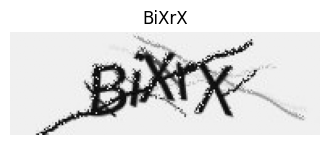

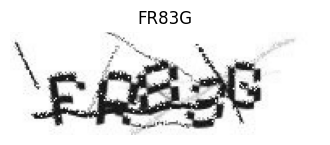

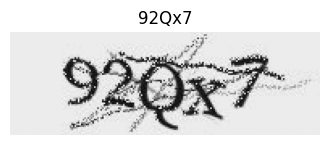

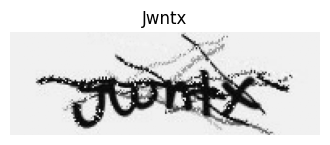

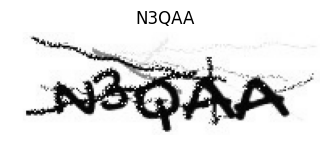

In [123]:
for i in range(5):
    img = images[i]
    label = labels[i]
    
    decoded = "".join(idx_to_char[int(c)] for c in label)
    img_np = img.squeeze().cpu().numpy()
    
    plt.figure(figsize=(4,2))
    plt.imshow(img_np, cmap="gray")
    plt.title(decoded)
    plt.axis("off")
    plt.show()

In [124]:
# =========================
# Initialize model
# =========================

model = FiveCharCaptchaCNN(
    num_char_classes=NUM_CHAR_CLASSES,
    label_length=LABEL_LENGTH
).to(DEVICE)

print(model)

FiveCharCaptchaCNN(
  (convolution): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, pad

In [125]:
# Move batch to device
images = images.to(DEVICE)
labels = labels.to(DEVICE)

# Forward pass
outputs = model(images)

print("\nForward pass results:")
print(f"Input shape:  {images.shape}")
print(f"Output shape: {outputs.shape}")


Forward pass results:
Input shape:  torch.Size([32, 1, 64, 192])
Output shape: torch.Size([32, 5, 51])


In [126]:
# =========================
# Loss test
# =========================

criterion = nn.CrossEntropyLoss()

# reshape for CrossEntropy
logits = outputs.view(-1, NUM_CHAR_CLASSES)
targets = labels.view(-1)

print(f"logits shape:  {logits.shape}")
print(f"targets shape: {targets.shape}")

loss = criterion(logits, targets)

print(f"\nLoss value: {loss.item()}")

logits shape:  torch.Size([160, 51])
targets shape: torch.Size([160])

Loss value: 3.96199369430542


In [127]:
# =========================
# Prediction decoding test
# =========================

preds = outputs.argmax(dim=-1)

true_string = "".join(idx_to_char[int(i)] for i in labels[0])
pred_string = "".join(idx_to_char[int(i)] for i in preds[0])

print("\nExample prediction:")
print(f"True: {true_string}")
print(f"Pred: {pred_string}")


Example prediction:
True: BiXrX
Pred: J9tnV


In [128]:
# =========================
# Optimizer + history
# =========================

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

history = {
    "train_loss": [],
    "val_loss": [],
    "train_char_acc": [],
    "val_char_acc": [],
    "train_seq_acc": [],
    "val_seq_acc": [],
    "val_pos_acc_0": [],
    "val_pos_acc_1": [],
    "val_pos_acc_2": [],
    "val_pos_acc_3": [],
    "val_pos_acc_4": [],
}

print("Optimizer, criterion, and history initialized.")

Optimizer, criterion, and history initialized.


In [129]:
# =========================
# Metric helpers
# =========================

def compute_metrics(outputs, labels):
    """
    outputs: [B, 5, 51]
    labels:  [B, 5]
    """
    preds = outputs.argmax(dim=-1)  # [B, 5]

    char_acc = (preds == labels).float().mean().item()
    seq_acc = (preds == labels).all(dim=1).float().mean().item()

    pos_accs = []
    for pos in range(labels.size(1)):
        pos_acc = (preds[:, pos] == labels[:, pos]).float().mean().item()
        pos_accs.append(pos_acc)

    return char_acc, seq_acc, pos_accs

In [130]:
# =========================
# Safe batch unpacking (if return_filenames is True)
# =========================
def unpack_batch(batch):
    if isinstance(batch, (list, tuple)):
        if len(batch) == 2:
            images, labels = batch
            filenames = None
        elif len(batch) == 3:
            images, labels, filenames = batch
        else:
            raise ValueError(f"Unexpected batch length: {len(batch)}")
    else:
        raise TypeError(f"Unexpected batch type: {type(batch)}")

    return images, labels, filenames

In [131]:
# =========================
# Train for one epoch
# =========================

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    running_char_acc = 0.0
    running_seq_acc = 0.0
    num_batches = 0

    for batch in loader:
        images, labels, filenames = unpack_batch(batch)
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)  # [B, 5, 51]
        loss = criterion(outputs.view(-1, NUM_CHAR_CLASSES), labels.view(-1))

        loss.backward()
        optimizer.step()

        char_acc, seq_acc, _ = compute_metrics(outputs, labels)

        running_loss += loss.item()
        running_char_acc += char_acc
        running_seq_acc += seq_acc
        num_batches += 1

    epoch_loss = running_loss / num_batches
    epoch_char_acc = running_char_acc / num_batches
    epoch_seq_acc = running_seq_acc / num_batches

    return epoch_loss, epoch_char_acc, epoch_seq_acc

In [132]:
# =========================
# Validate for one epoch
# =========================

def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_char_acc = 0.0
    running_seq_acc = 0.0
    running_pos_accs = [0.0] * LABEL_LENGTH
    num_batches = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels, filenames = unpack_batch(batch)
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs.view(-1, NUM_CHAR_CLASSES), labels.view(-1))

            char_acc, seq_acc, pos_accs = compute_metrics(outputs, labels)

            running_loss += loss.item()
            running_char_acc += char_acc
            running_seq_acc += seq_acc

            for i in range(LABEL_LENGTH):
                running_pos_accs[i] += pos_accs[i]

            num_batches += 1

    epoch_loss = running_loss / num_batches
    epoch_char_acc = running_char_acc / num_batches
    epoch_seq_acc = running_seq_acc / num_batches
    epoch_pos_accs = [x / num_batches for x in running_pos_accs]

    return epoch_loss, epoch_char_acc, epoch_seq_acc, epoch_pos_accs

In [133]:
# =========================
# Full training loop
# =========================

best_val_seq_acc = -1.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_char_acc, train_seq_acc = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE,
    )

    val_loss, val_char_acc, val_seq_acc, val_pos_accs = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE,
    )

    # Save metrics
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_char_acc"].append(train_char_acc)
    history["val_char_acc"].append(val_char_acc)
    history["train_seq_acc"].append(train_seq_acc)
    history["val_seq_acc"].append(val_seq_acc)

    for i in range(LABEL_LENGTH):
        history[f"val_pos_acc_{i}"].append(val_pos_accs[i])

    # Epoch panel
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Train Char Acc: {train_char_acc:.4f} | Val Char Acc: {val_char_acc:.4f}")
    print(f"Train Seq Acc:  {train_seq_acc:.4f} | Val Seq Acc:  {val_seq_acc:.4f}")
    print("Val Pos Accs:", [f"{acc:.4f}" for acc in val_pos_accs])

    # Save best model
    if val_seq_acc > best_val_seq_acc:
        best_val_seq_acc = val_seq_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"New best model saved to: {BEST_MODEL_PATH}")

# Save last model
torch.save(model.state_dict(), LAST_MODEL_PATH)
print(f"\nLast model saved to: {LAST_MODEL_PATH}")


Epoch [1/30]
Train Loss: 3.9711 | Val Loss: 3.9230
Train Char Acc: 0.0125 | Val Char Acc: 0.0500
Train Seq Acc:  0.0000 | Val Seq Acc:  0.0000
Val Pos Accs: ['0.0312', '0.0625', '0.0312', '0.0625', '0.0625']
New best model saved to: /Users/marc/Documents/VS-Code Projects/captcha-ai/experiments/test_run_20260315_233040/best_model.pt



Epoch [2/30]
Train Loss: 3.6002 | Val Loss: 3.9042
Train Char Acc: 0.1187 | Val Char Acc: 0.0625
Train Seq Acc:  0.0000 | Val Seq Acc:  0.0000
Val Pos Accs: ['0.0625', '0.0625', '0.0625', '0.0625', '0.0625']

Epoch [3/30]
Train Loss: 3.2771 | Val Loss: 3.8779
Train Char Acc: 0.2250 | Val Char Acc: 0.0625
Train Seq Acc:  0.0000 | Val Seq Acc:  0.0000
Val Pos Accs: ['0.0625', '0.0625', '0.0625', '0.0625', '0.0625']

Epoch [4/30]
Train Loss: 3.0384 | Val Loss: 3.8468
Train Char Acc: 0.2250 | Val Char Acc: 0.0625
Train Seq Acc:  0.0000 | Val Seq Acc:  0.0000
Val Pos Accs: ['0.0625', '0.0625', '0.0625', '0.0625', '0.0625']

Epoch [5/30]
Train Loss: 2.7072 | Val Loss: 3.8143
Train Char Acc: 0.3000 | Val Char Acc: 0.0625
Train Seq Acc:  0.0000 | Val Seq Acc:  0.0000
Val Pos Accs: ['0.0625', '0.0625', '0.0625', '0.0625', '0.0625']

Epoch [6/30]
Train Loss: 2.4443 | Val Loss: 3.7828
Train Char Acc: 0.4688 | Val Char Acc: 0.0625
Train Seq Acc:  0.0312 | Val Seq Acc:  0.0000
Val Pos Accs: ['0.06

In [134]:
# =========================
# Save training history
# =========================

with open(HISTORY_PATH, "w") as f:
    json.dump(history, f, indent=4)

print(f"Training history saved to: {HISTORY_PATH}")

Training history saved to: /Users/marc/Documents/VS-Code Projects/captcha-ai/experiments/test_run_20260315_233040/training_history.json


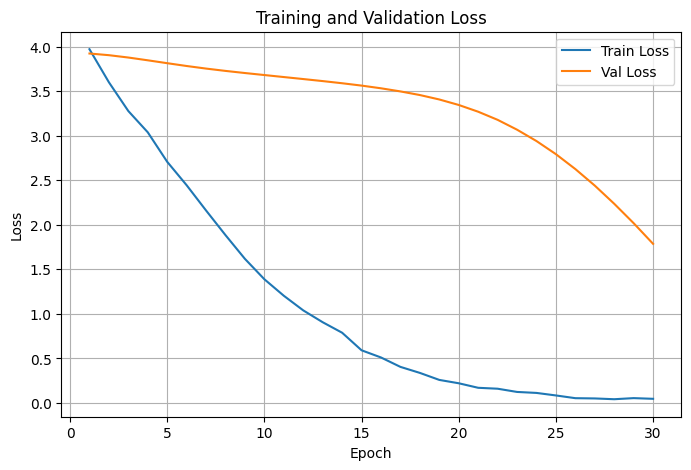

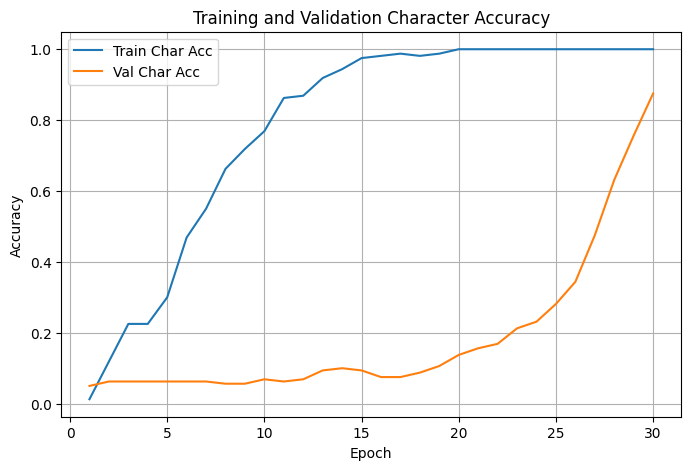

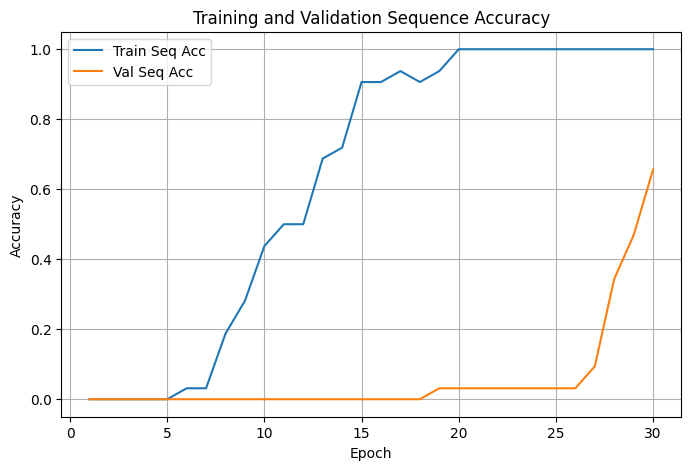

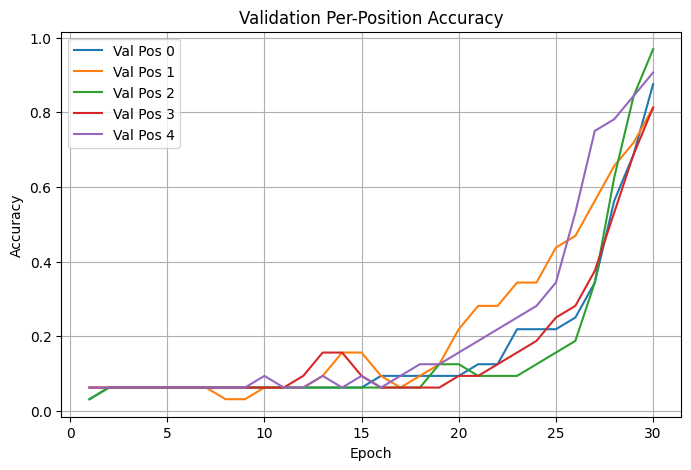

In [135]:
# =========================
# Plot training curves
# =========================

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
if SAVE_PLOTS:
    plt.savefig(CURVES_PATH.with_name("loss_" + CURVES_PATH.name), bbox_inches="tight")
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_char_acc"], label="Train Char Acc")
plt.plot(epochs, history["val_char_acc"], label="Val Char Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Character Accuracy")
plt.legend()
plt.grid(True)
if SAVE_PLOTS:
    plt.savefig(CURVES_PATH.with_name("char_acc_" + CURVES_PATH.name), bbox_inches="tight")
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_seq_acc"], label="Train Seq Acc")
plt.plot(epochs, history["val_seq_acc"], label="Val Seq Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Sequence Accuracy")
plt.legend()
plt.grid(True)
if SAVE_PLOTS:
    plt.savefig(CURVES_PATH.with_name("seq_acc_" + CURVES_PATH.name), bbox_inches="tight")
plt.show()


plt.figure(figsize=(8, 5))
for i in range(LABEL_LENGTH):
    plt.plot(epochs, history[f"val_pos_acc_{i}"], label=f"Val Pos {i}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Per-Position Accuracy")
plt.legend()
plt.grid(True)
if SAVE_PLOTS:
    plt.savefig(CURVES_PATH.with_name("val_pos_acc_" + CURVES_PATH.name), bbox_inches="tight")
plt.show()

In [136]:
# =========================
# Inspect validation predictions
# =========================

model.eval()

num_examples_to_show = 8

with torch.no_grad():
    batch = next(iter(val_loader))
    images, labels, filenames = unpack_batch(batch)

    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    outputs = model(images)
    preds = outputs.argmax(dim=-1)

for i in range(min(num_examples_to_show, images.size(0))):
    true_string = "".join(idx_to_char[int(x)] for x in labels[i])
    pred_string = "".join(idx_to_char[int(x)] for x in preds[i])

    print(f"Example {i+1}")
    print(f"True: {true_string}")
    print(f"Pred: {pred_string}")
    if filenames is not None:
        print(f"File: {filenames[i]}")
    print("-" * 30)

Example 1
True: qE6pi
Pred: w6xNY
------------------------------
Example 2
True: nmuMf
Pred: w6xN7
------------------------------
Example 3
True: TtDyP
Pred: FKxN7
------------------------------
Example 4
True: bcffM
Pred: F6wN7
------------------------------
Example 5
True: LrAdh
Pred: F6QN7
------------------------------
Example 6
True: gENj7
Pred: w6xN7
------------------------------
Example 7
True: VBCnR
Pred: w6xNX
------------------------------
Example 8
True: ACWRB
Pred: w6xN7
------------------------------


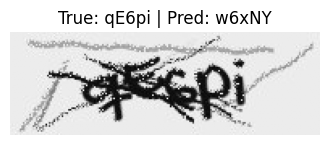

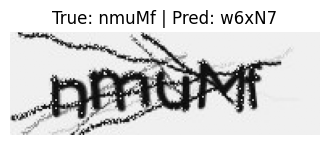

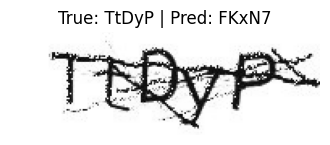

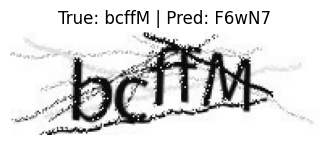

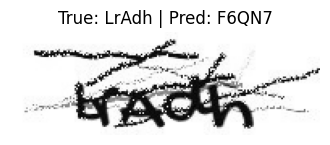

In [137]:
# =========================
# Show validation images with true/pred labels
# =========================

num_images_to_show = 5

for i in range(min(num_images_to_show, images.size(0))):
    img_np = images[i].detach().cpu().squeeze().numpy()
    true_string = "".join(idx_to_char[int(x)] for x in labels[i])
    pred_string = "".join(idx_to_char[int(x)] for x in preds[i])

    plt.figure(figsize=(4, 2))
    plt.imshow(img_np, cmap="gray")
    plt.title(f"True: {true_string} | Pred: {pred_string}")
    plt.axis("off")
    plt.show()

In [138]:
print(f"Train dataset size: {len(train_loader.dataset)}")
print(f"Val dataset size:   {len(val_loader.dataset)}")
print(f"Test dataset size:  {len(test_loader.dataset)}")
print(f"Subset fraction:    {SUBSET_FRACTION}")

Train dataset size: 32
Val dataset size:   32
Test dataset size:  200
Subset fraction:    1.0


In [139]:
# Training batch predictions
model.eval()

with torch.no_grad():
    train_batch = next(iter(train_loader))
    train_images, train_labels, _ = unpack_batch(train_batch)
    train_images = train_images.to(DEVICE)
    train_labels = train_labels.to(DEVICE)

    train_outputs = model(train_images)
    train_preds = train_outputs.argmax(dim=-1)

print("TRAIN BATCH")
for i in range(5):
    true_string = "".join(idx_to_char[int(x)] for x in train_labels[i])
    pred_string = "".join(idx_to_char[int(x)] for x in train_preds[i])
    print(f"True: {true_string} | Pred: {pred_string}")

TRAIN BATCH
True: N3QAA | Pred: N3QAA
True: HtEQR | Pred: HtENR
True: m3X68 | Pred: m6XNY
True: gCwhX | Pred: wCwhX
True: 76LyW | Pred: 76LyW


In [140]:
model.eval()

with torch.no_grad():
    batch = next(iter(val_loader))
    images, labels, _ = unpack_batch(batch)

    images = images.to(DEVICE)
    outputs = model(images)
    preds = outputs.argmax(dim=-1).cpu()

for pos in range(LABEL_LENGTH):
    unique_preds = torch.unique(preds[:, pos])
    decoded = [idx_to_char[int(x)] for x in unique_preds]
    print(f"Position {pos}: {decoded}")

Position 0: ['F', 'k', 'w', 'y']
Position 1: ['6', '9', 'C', 'K', 'R']
Position 2: ['Q', 'w', 'x']
Position 3: ['C', 'N', 'x']
Position 4: ['3', '7', '9', 'F', 'X', 'Y', 'w']


In [141]:
sample_logits = outputs[0].detach().cpu()  # [5, 51]

for pos in range(LABEL_LENGTH):
    probs = torch.softmax(sample_logits[pos], dim=0)
    top_probs, top_idxs = torch.topk(probs, k=5)
    top_chars = [idx_to_char[int(i)] for i in top_idxs]
    print(f"Position {pos}:")
    for ch, p in zip(top_chars, top_probs):
        print(f"  {ch}: {p.item():.4f}")

Position 0:
  w: 0.1821
  9: 0.0743
  B: 0.0676
  L: 0.0635
  W: 0.0554
Position 1:
  6: 0.1793
  P: 0.1238
  9: 0.0857
  2: 0.0717
  C: 0.0636
Position 2:
  x: 0.1979
  w: 0.0929
  Q: 0.0767
  3: 0.0556
  m: 0.0528
Position 3:
  N: 0.1676
  x: 0.1278
  C: 0.0823
  e: 0.0673
  c: 0.0475
Position 4:
  Y: 0.1420
  7: 0.1250
  X: 0.0997
  w: 0.0690
  9: 0.0580


# TO DO:
- Clean up notebook work space
- Consolidate Core code
- Consolitdate Metrics
- Test/Debug

Once Functioning is appropiate: Large scale training